<a href="https://colab.research.google.com/github/sarathkurapati/ml-dl-notebooks/blob/main/ADVERTISING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
df=pd.read_csv("Advertising.csv")

In [72]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [73]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [74]:
df.sample(5)

,Unnamed: 0,TV,Radio,Newspaper,Sales
111,112,241.7,38.0,23.2,21.8
70,71,199.1,30.6,38.7,18.3
128,129,220.3,49.0,3.2,24.7
135,136,48.3,47.0,8.5,11.6
11,12,214.7,24.0,4.0,17.4


CHECKING NULL VALUES

In [75]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [76]:
df.isnull().any()

Unnamed: 0    False
TV            False
Radio         False
Newspaper     False
Sales         False
dtype: bool

EDA

In [77]:
df.describe(include="all")

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [79]:
df.shape

(200, 5)

REMOVING COLUMNS

In [80]:
df.head(2)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4


In [81]:
df.drop(df.columns[0],axis=1,inplace=True)

In [82]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [105]:
x=df.drop(columns="Sales",axis=1)
x.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [121]:
y=df[["Sales"]]
y.head()

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [122]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [123]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((160, 3), (40, 3), (160, 1), (40, 1))

In [124]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()
lm.fit(x_train,y_train)

LinearRegression()

In [125]:
y_pred=lm.predict(x_test)

In [126]:
y_pred

array([[10.05739563],
       [ 7.4522807 ],
       [ 7.0197076 ],
       [24.08029725],
       [12.01786259],
       [ 6.53793858],
       [12.78286918],
       [15.10974587],
       [10.76974013],
       [16.34357951],
       [22.88297477],
       [ 9.12924467],
       [10.46455672],
       [15.48743552],
       [11.58555633],
       [12.17296914],
       [18.76551502],
       [10.78318566],
       [15.90515992],
       [17.30651279],
       [24.06692057],
       [ 9.59834224],
       [15.13512211],
       [12.38591525],
       [ 5.71360885],
       [15.24749314],
       [12.29402334],
       [20.9421167 ],
       [13.40991558],
       [ 9.04348832],
       [12.89239415],
       [21.40272028],
       [18.13802209],
       [21.17320803],
       [ 6.56974433],
       [ 6.14114206],
       [ 7.89018394],
       [13.01541434],
       [14.68953791],
       [ 6.18835143]])

In [127]:
from sklearn.metrics import mean_squared_error,r2_score
r2score=r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [128]:
r2score

0.8601145185017868

In [129]:
mse

4.402118291449685

TV SALES

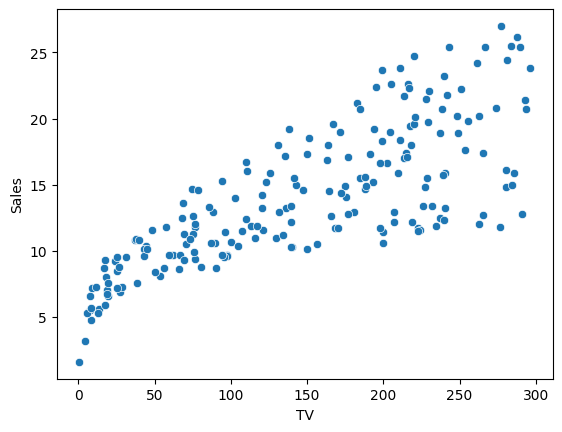

In [117]:
sns.scatterplot(x=df.TV,y=df.Sales)
plt.show()

RADIO SALES

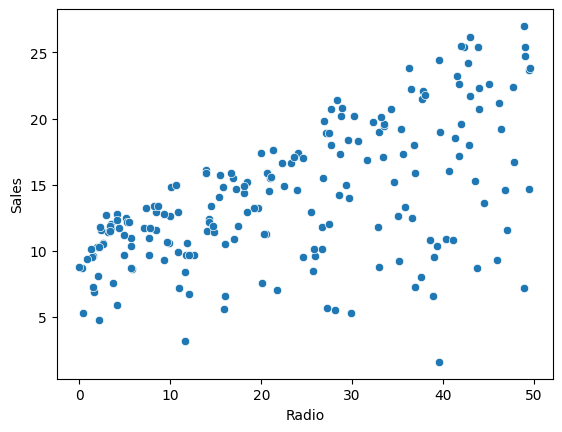

In [118]:
sns.scatterplot(x=df.Radio,y=df.Sales)
plt.show()

<Axes: xlabel='Newspaper', ylabel='Sales'>

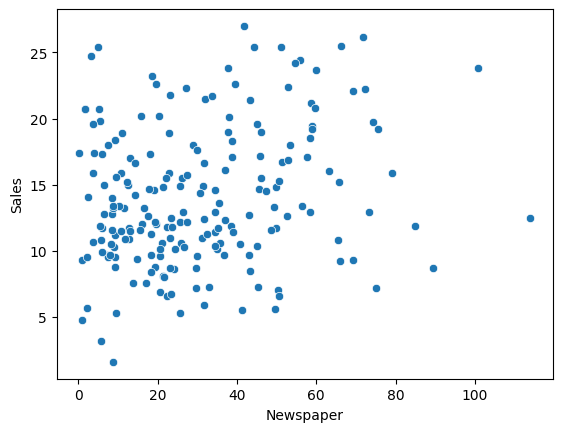

In [119]:
sns.scatterplot(x=df.Newspaper,y=df.Sales)

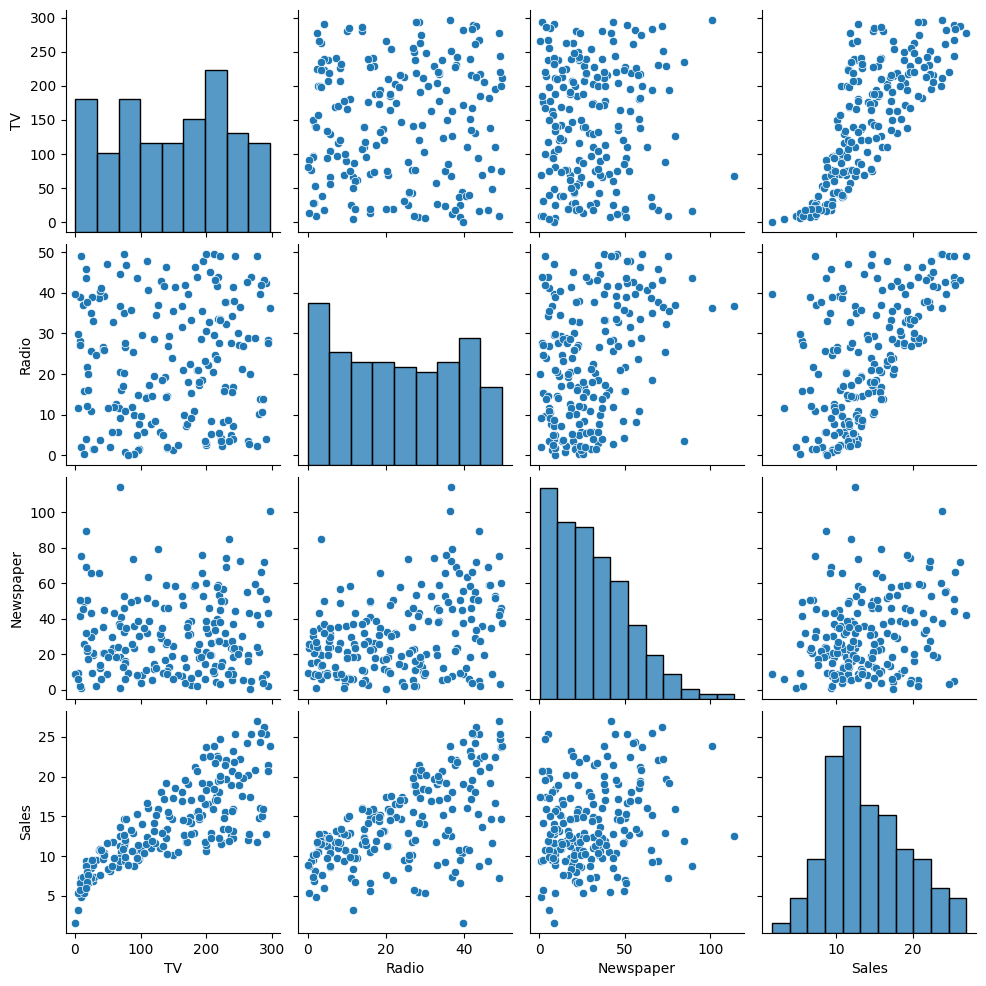

In [101]:
sns.pairplot(df)

performing the MINMAXSCALER TO THE MODEL

In [130]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
x_scaled=pd.DataFrame(scale.fit_transform(x),columns = x.columns)
y_scaled= pd.DataFrame(scale.fit_transform(y),columns = y.columns)

In [131]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y_scaled,test_size=0.2,random_state=0)

In [132]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((160, 3), (40, 3), (160, 1), (40, 1))

In [134]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [135]:
y_prediction=model.predict(x_test)

In [136]:
from sklearn.metrics import mean_squared_error,r2_score
scaled_r2score=r2_score(y_test, y_pred)
scaled_mse = mean_squared_error(y_test, y_pred)

In [137]:
scaled_r2score

-3885.9670430500364

In [138]:
scaled_mse

189.59744980991837

QUESTION

In [139]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [140]:
lm.coef_

array([[ 0.51903523,  0.38371074, -0.01245088]])

In [141]:
lm.intercept_

array([0.05611289])

In [142]:
model.coef_

array([[ 0.51903523,  0.38371074, -0.01245088]])

In [143]:
model.intercept_

array([0.05611289])